In [66]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(Path.cwd())

d:\Anisha\Job\Aston_University\EuroSAT\notebooks


In [67]:
from src.dataloader_fusion import get_dataloader_fusion
from src.train_fusion import training_loop_fusion
from src.evaluation import plot_all_evaluation
from src.model_fusion import *

In [68]:
device = get_device()

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6


In [4]:
train_fusion_loader, val_fusion_loader, test_fusion_loader = get_dataloader_fusion()

rgb_images, ms_images, labels = next(iter(train_fusion_loader))

print('RGB Shape: ', rgb_images.shape)
print('MS Shape: ', ms_images.shape)
print('Labels shape: ', labels.shape)
print('RGB min/max: ', rgb_images.min().item(), rgb_images.max().item())
print('MS min/max: ', ms_images.min().item(), ms_images.max().item())
print('Labels min/max: ', labels.min().item(), labels.max().item())



RGB Shape:  torch.Size([64, 3, 64, 64])
MS Shape:  torch.Size([64, 13, 64, 64])
Labels shape:  torch.Size([64])
RGB min/max:  0.07450980693101883 1.0
MS min/max:  0.00019999999494757503 0.7382000088691711
Labels min/max:  0 9


In [5]:
model_fusion = FusionResNet18(
    rgb_checkpoint='rgb_resnet18_v2.pth',
    ms_checkpoint='ms_resnet18_v1.pth',
    freeze=False
).to(device)

rgb_images = rgb_images.to(device)
ms_images = ms_images.to(device)

output = model_fusion(rgb_images, ms_images)

print('RGB Shape: ', rgb_images.shape)
print('MS Shape: ', ms_images.shape)
print('Labels shape: ', labels.shape)
print('RGB min/max: ', rgb_images.min().item(), rgb_images.max().item())
print('MS min/max: ', ms_images.min().item(), ms_images.max().item())
print('Labels min/max: ', labels.min().item(), labels.max().item())
print('Output Shape: ', output.shape)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Loaded RGB Model Checkpoint.
Loaded MS Model Checkpoint.
RGB Shape:  torch.Size([64, 3, 64, 64])
MS Shape:  torch.Size([64, 13, 64, 64])
Labels shape:  torch.Size([64])
RGB min/max:  0.07450980693101883 1.0
MS min/max:  0.00019999999494757503 0.7382000088691711
Labels min/max:  0 9
Output Shape:  torch.Size([64, 10])


In [69]:
import src.evaluation
import src.utils
import importlib

importlib.reload(src.evaluation)
importlib.reload(src.utils)

<module 'src.utils' from 'd:\\Anisha\\Job\\Aston_University\\EuroSAT\\src\\utils.py'>

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_fusion.parameters(),
    lr=LEARNING_RATE,
    weight_decay = 1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max',
    factor=0.5, patience=3
)

history_fusion = training_loop_fusion(
    train_fusion_loader, val_fusion_loader,
    model_fusion, criterion, optimizer,
    'fusion_resnet18_v1.pth', scheduler
)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Epoch [1/30]Train Loss: 0.0942Train Acc: 0.9786Val Loss: 0.0724Val Acc: 0.9781LR: 0.000100
New Best Fusion Model Saved. Val Acc: 0.9781
Epoch [2/30]Train Loss: 0.0280Train Acc: 0.9910Val Loss: 0.0475Val Acc: 0.9840LR: 0.000100
New Best Fusion Model Saved. Val Acc: 0.9840
Epoch [3/30]Train Loss: 0.0236Train Acc: 0.9925Val Loss: 0.0658Val Acc: 0.9799LR: 0.000100
Epoch [4/30]Train Loss: 0.0248Train Acc: 0.9925Val Loss: 0.0922Val Acc: 0.9759LR: 0.000100
Epoch [5/30]Train Loss: 0.0159Train Acc: 0.9951Val Loss: 0.0583Val Acc: 0.9836LR: 0.000100
Epoch [6/30]Train Loss: 0.0125Train Acc: 0.9966Val Loss: 0.0727Val Acc: 0.9812LR: 0.000050
Epoch [7/30]Train Loss: 0.0047Train Acc: 0.9984Val Loss: 0.0557Val Acc: 0.9843LR: 0.000050
New Best Fusion Model Saved. Val Acc: 0.9843
Epoch [8/30]Train Loss: 0.0038Train Acc: 0.9990Val Loss: 0.0536Val Acc: 0.9858LR: 0.000050
New Best Fusion Model Saved. Val Acc: 0.9858
Epoch [9/30]Train Loss: 0.0027Train Acc:

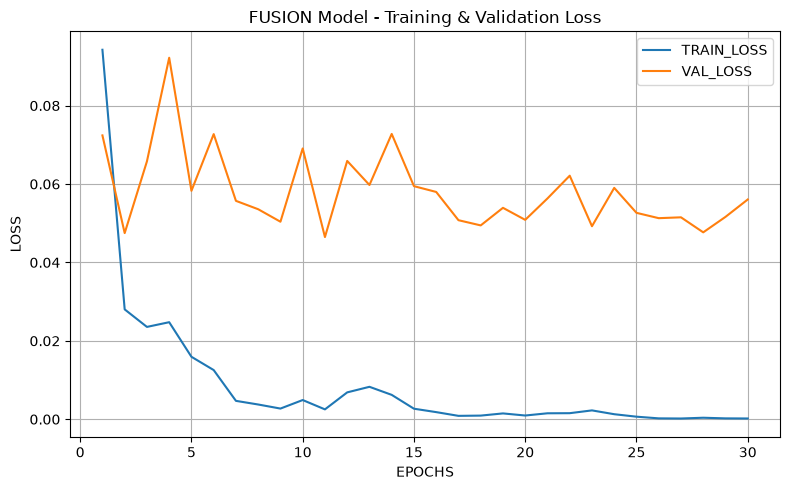

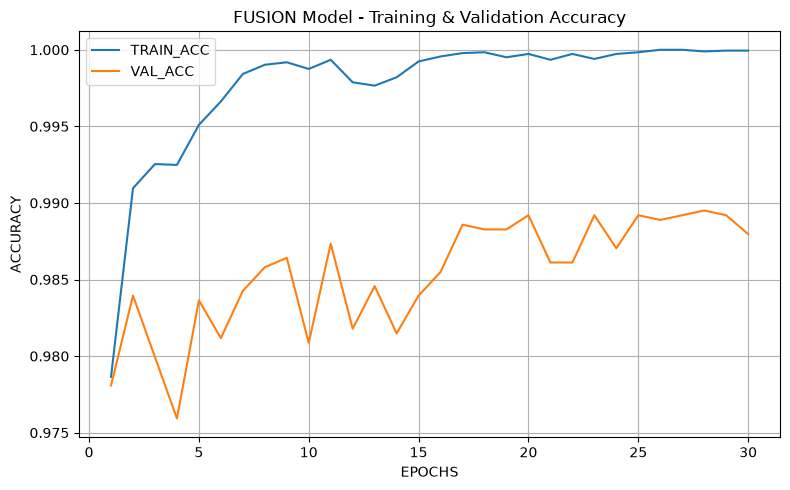

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
   accuracy  macro_precision  macro_recall  macro_f1
0  0.986667         0.986633      0.985867  0.986227
                      precision    recall  f1-score      support
AnnualCrop             0.973554  0.981667  0.977593   600.000000
Forest                 1.000000  0.993333  0.996656   600.000000
HerbaceousVegetation   0.978477  0.985000  0.981728   600.000000
Highway                0.991935  0.984000  0.987952   500.000000
Industrial             0.989899  0.980000  0.984925   500.000000
Pasture                0.984772  0.970000  0.977330   400.000000
PermanentCrop          0.962525  0.976000  0.969215   500.000000
Residential            0.985173  0.996667  0.990886   600.000000
River                  1.000000  0.992000  0.995984   500.000000
SeaLake                1.000000  1.000000  1.000000   600.000000
accuracy               0.986667  0.986667  0.986667     0.986667
macro avg              0.986633  0.985867  0.986227  5400.0000

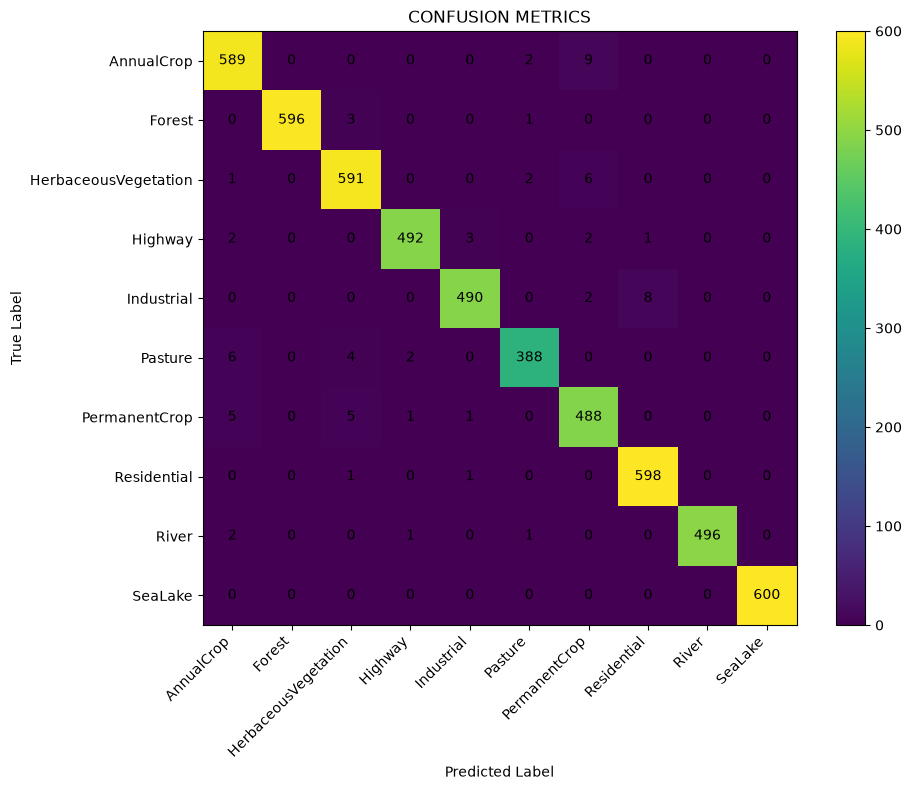

In [70]:
plot_all_evaluation(history_fusion, model_fusion, test_fusion_loader, 'fusion')

# Freezing the RGB and MS - V2

In [71]:
model_fusion = FusionResNet18(
    rgb_checkpoint='rgb_resnet18_v2.pth',
    ms_checkpoint='ms_resnet18_v1.pth',
    freeze=True
).to(device)

rgb_images = rgb_images.to(device)
ms_images = ms_images.to(device)

output = model_fusion(rgb_images, ms_images)

print('RGB Shape: ', rgb_images.shape)
print('MS Shape: ', ms_images.shape)
print('Labels shape: ', labels.shape)
print('RGB min/max: ', rgb_images.min().item(), rgb_images.max().item())
print('MS min/max: ', ms_images.min().item(), ms_images.max().item())
print('Labels min/max: ', labels.min().item(), labels.max().item())
print('Output Shape: ', output.shape)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Loaded RGB Model Checkpoint.
Loaded MS Model Checkpoint.
RGB Shape:  torch.Size([64, 3, 64, 64])
MS Shape:  torch.Size([64, 13, 64, 64])
Labels shape:  torch.Size([64])
RGB min/max:  0.07450980693101883 1.0
MS min/max:  0.00019999999494757503 0.7382000088691711
Labels min/max:  0 9
Output Shape:  torch.Size([64, 10])


In [72]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_fusion.parameters()),
    lr=LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max',
    factor=0.5, patience=3
)

history_fusion = training_loop_fusion(
    train_fusion_loader, val_fusion_loader,
    model_fusion, criterion, optimizer,
    'fusion_resnet18_v1.pth', scheduler
)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Epoch [1/30]Train Loss: 0.1400Train Acc: 0.9733Val Loss: 0.0567Val Acc: 0.9818LR: 0.000100
New Best Fusion Model Saved. Val Acc: 0.9818
Epoch [2/30]Train Loss: 0.0326Train Acc: 0.9900Val Loss: 0.0485Val Acc: 0.9827LR: 0.000100
New Best Fusion Model Saved. Val Acc: 0.9827
Epoch [3/30]Train Loss: 0.0302Train Acc: 0.9895Val Loss: 0.0475Val Acc: 0.9855LR: 0.000100
New Best Fusion Model Saved. Val Acc: 0.9855
Epoch [4/30]Train Loss: 0.0259Train Acc: 0.9914Val Loss: 0.0453Val Acc: 0.9836LR: 0.000100
Epoch [5/30]Train Loss: 0.0228Train Acc: 0.9918Val Loss: 0.0455Val Acc: 0.9846LR: 0.000100
Epoch [6/30]Train Loss: 0.0252Train Acc: 0.9913Val Loss: 0.0446Val Acc: 0.9843LR: 0.000100
Epoch [7/30]Train Loss: 0.0213Train Acc: 0.9925Val Loss: 0.0464Val Acc: 0.9840LR: 0.000050
Epoch [8/30]Train Loss: 0.0191Train Acc: 0.9926Val Loss: 0.0441Val Acc: 0.9855LR: 0.000050
Epoch [9/30]Train Loss: 0.0160Train Acc: 0.9944Val Loss: 0.0456Val Acc: 0.9840LR: 0.0

In [74]:
# should have checked this before training
 
total_params = sum(p.numel() for p in model_fusion.parameters())
trainable_params = sum(p.numel() for p in model_fusion.parameters() if p.requires_grad)

print('Total Params: ', total_params)
print('Trainable Params: ', trainable_params)

Total Params:  22914314
Trainable Params:  529930


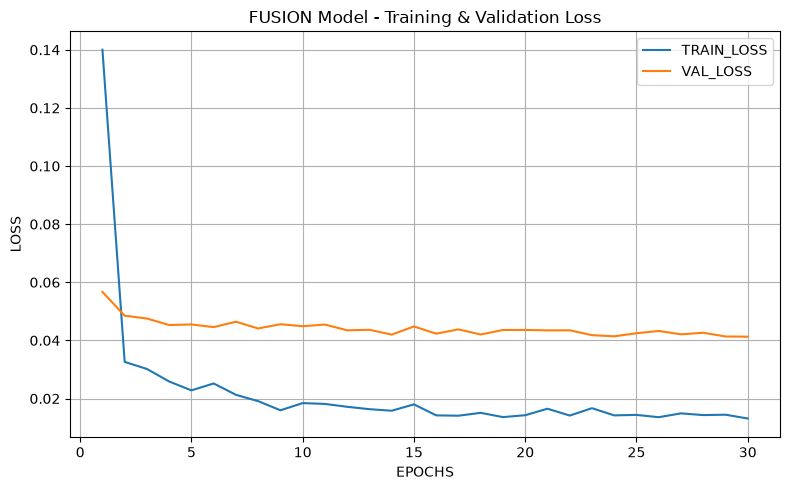

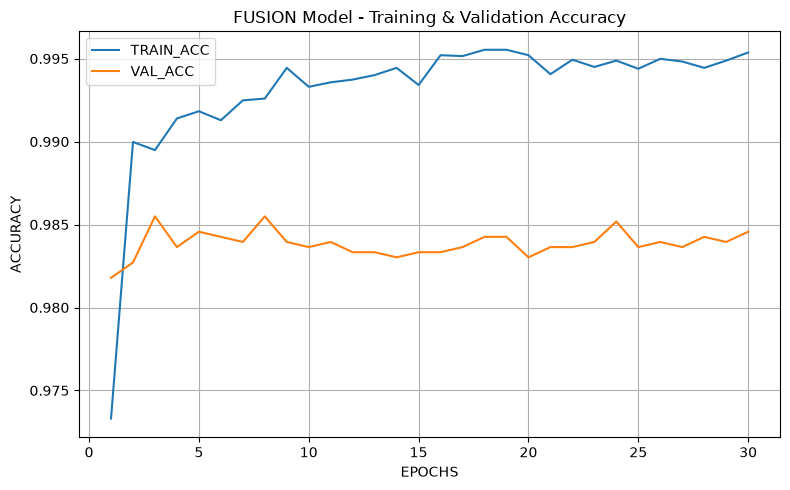

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
   accuracy  macro_precision  macro_recall  macro_f1
0  0.982963         0.982797      0.982467   0.98261
                      precision    recall  f1-score      support
AnnualCrop             0.965232  0.971667  0.968439   600.000000
Forest                 0.991722  0.998333  0.995017   600.000000
HerbaceousVegetation   0.974958  0.973333  0.974145   600.000000
Highway                0.991919  0.982000  0.986935   500.000000
Industrial             0.980000  0.980000  0.980000   500.000000
Pasture                0.970297  0.980000  0.975124   400.000000
PermanentCrop          0.973577  0.958000  0.965726   500.000000
Residential            0.980263  0.993333  0.986755   600.000000
River                  1.000000  0.988000  0.993964   500.000000
SeaLake                1.000000  1.000000  1.000000   600.000000
accuracy               0.982963  0.982963  0.982963     0.982963
macro avg              0.982797  0.982467  0.982610  5400.0000

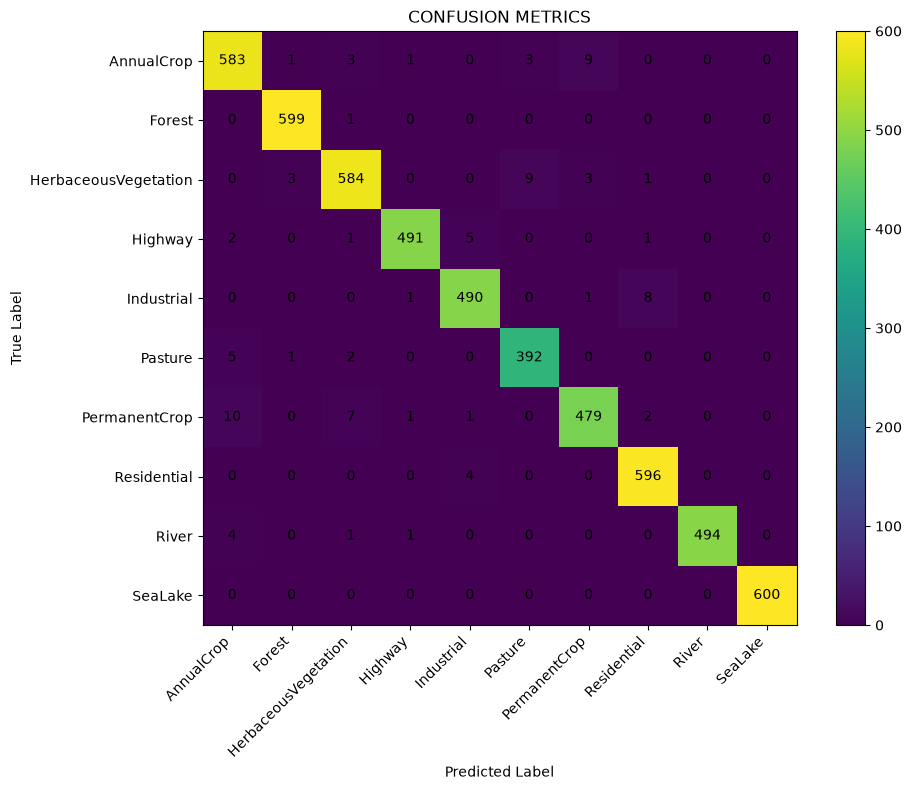

In [75]:
plot_all_evaluation(history_fusion, model_fusion, test_fusion_loader, 'fusion')